# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [1]:
%pip install transformers torch tqdm datasets

Note: you may need to restart the kernel to use updated packages.


In [29]:
from pathlib import Path
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForMaskedLM, BertForSequenceClassification
from datasets import Dataset, load_from_disk, load_dataset

import configuration
from src import setup, data_utils
from src.models import bert

## B. Data Loading

In [3]:
data_frac = data_utils.DATA_FRACTION

In [4]:
df_train, df_val, df_test = data_utils.load_datasets()

# Load data as Hugging Face Datasets
ds_train, ds_val, ds_test = bert.create_datasets(df_train, df_val, df_test)

## C. Tokenization

In [5]:
# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

### C.1. Quick preview on dataset to find optimal parameter for `tokenizer`

In [6]:
bert.max_length_dist(df_train, 'tweet_text', tokenizer)

90th percentile: 45.0
95th percentile: 50.0
99th percentile: 61.0
Absolute Maximum length: 158


So, set the `max_length` to `64`.

### C.2. Do the Tokenization

In [7]:
save_path = Path(f"../tokens/BERT/{data_frac}")
train_tokenized, val_tokenized, test_tokenized = bert.load_or_tokenize(ds_train, ds_val, ds_test, tokenizer, save_path)

Loading tokenized datasets from disk...


## B. Fine-tuning BERT

### B.0. Shrink dataset size for development purpose

In [11]:
# Comment out this cell to use the full dataset. This is just for quick testing.
train_size = 5000
train_tokenized = train_tokenized.select(range(train_size))
val_tokenized = val_tokenized.select(range(int(train_size / 4)))
test_tokenized = test_tokenized.select(range(int(train_size / 4)))

### B.1. Preparation

In [12]:
device = setup.setup_device_with_seeds()

batch_size = 16
learning_rate = 5e-5
num_epochs = 3
patience = 2  # early stopping, if validation loss does not improve for this many epochs

train_loader = DataLoader(train_tokenized, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(val_tokenized, batch_size=batch_size)

# Optimizer
bert_base = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2  # e.g., binary sentiment
)
bert_base.config.problem_type = "single_label_classification"
optimizer = AdamW(bert_base.parameters(), lr=learning_rate)

configs = {
    "batch_size": batch_size,
    "bert": bert_base,
    "optimizer": optimizer,
    "device": device,
    "num_epochs": num_epochs,
    "patience": patience
}

Using device: mps


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### B.2. Fine-tune

In [13]:
model, train_loss_history, val_loss_history, val_acc_history = bert.finetune(train_tokenized, val_tokenized, configs)

Starting BertForSequenceClassification fine-tuning...
Using device: mps
Number of training samples: 5000
Number of validation samples: 1250
Batch size: 16
Number of epochs: 3
Early stopping patience: 2 epochs
--------------------------------------------------


Validating Epoch 1/3: 100%|██████████| 79/79 [00:12<00:00,  6.34it/s]


Epoch 1/3 | Train Loss: 0.2195 | Val Loss: 0.1881 | Val Acc: 0.9400


Validating Epoch 2/3: 100%|██████████| 79/79 [00:10<00:00,  7.31it/s]


Epoch 2/3 | Train Loss: 0.1020 | Val Loss: 0.1477 | Val Acc: 0.9456


Validating Epoch 3/3: 100%|██████████| 79/79 [00:11<00:00,  6.89it/s]


Epoch 3/3 | Train Loss: 0.0539 | Val Loss: 0.2180 | Val Acc: 0.9352
Loaded best model with Val Loss: 0.1477


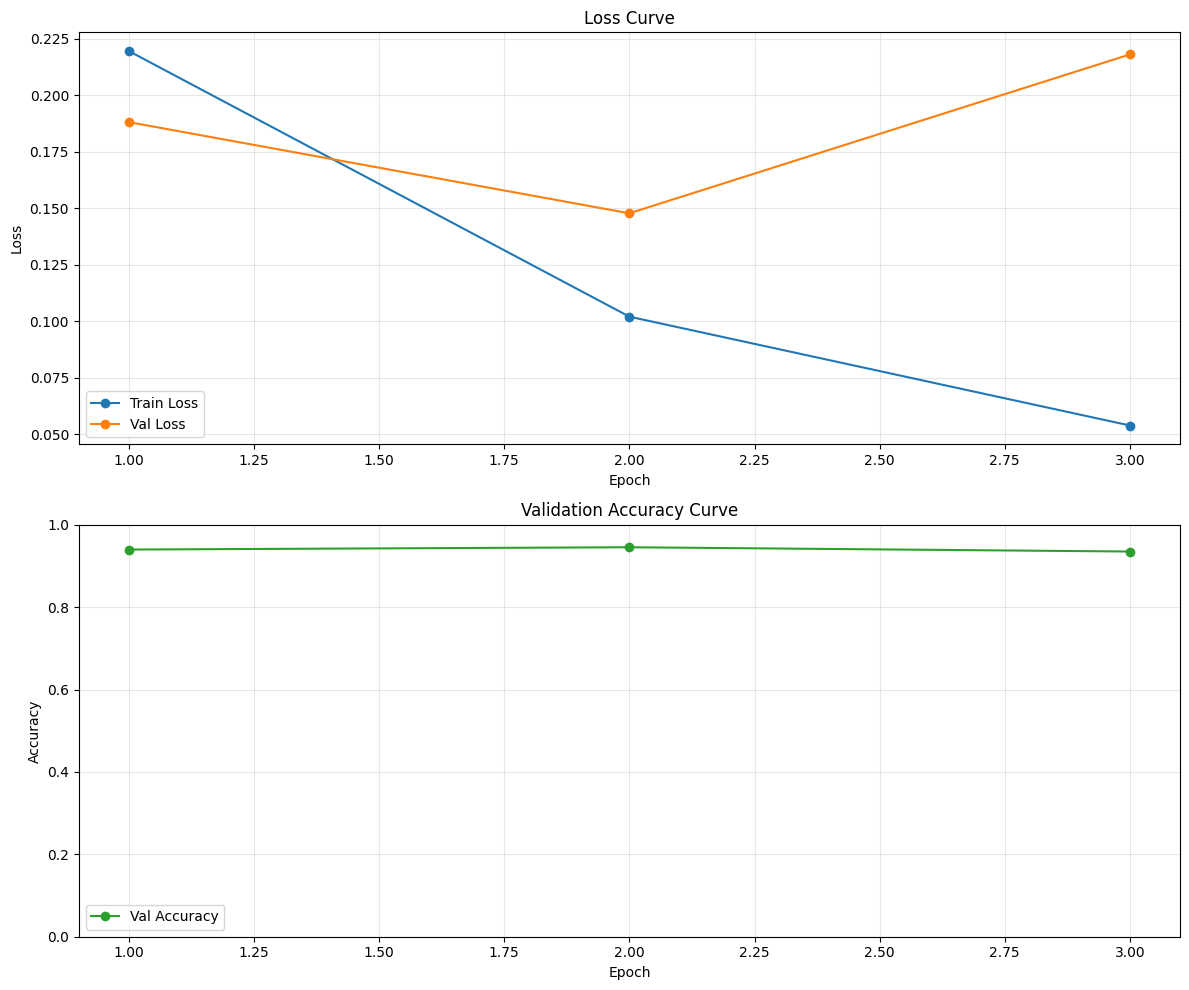

In [22]:
data_utils.plot_fine_tune_history(train_loss_history, val_loss_history, val_acc_history)

### B.3. Predict on the Test set

In [15]:
predictions = bert.predict(model, test_tokenized, device)

Predicting on Test Set: 100%|██████████| 79/79 [00:11<00:00,  7.09it/s]


In [41]:
bert.report_metrics(test_tokenized, predictions)


Classification report:
              precision    recall  f1-score   support

           0     0.9767    0.9495    0.9629       970
           1     0.8404    0.9214    0.8790       280

    accuracy                         0.9432      1250
   macro avg     0.9085    0.9355    0.9210      1250
weighted avg     0.9461    0.9432    0.9441      1250

